In [1]:
import numpy as np
import pandas as pd
import scanpy as sc

In [2]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scanpy==1.9.1 anndata==0.8.0 umap==0.5.3 numpy==1.23.5 scipy==1.10.0 pandas==1.5.3 scikit-learn==1.2.1 statsmodels==0.13.5 python-igraph==0.10.4 pynndescent==0.5.8


In [3]:
adata = sc.read_h5ad('GSE175533_sceasy_hay.h5ad') 

In [4]:
adata_genes = sc.get.obs_df(
    adata,
    keys=['MKI67', 'TOP2A']
)

In [5]:
adata_genes.max()

MKI67    2.268107
TOP2A    2.296617
dtype: float32

In [6]:
adata.X[40:50,40:50]

<10x10 sparse matrix of type '<class 'numpy.float32'>'
	with 44 stored elements in Compressed Sparse Column format>

In [7]:
adata


AnnData object with n_obs × n_vars = 12019 × 33538
    obs: 'nCount_RNA', 'nFeature_RNA', 'barcode', 'PDL', 'sample', 'exp', 'S.Score', 'G2M.Score', 'Phase', 'nCount_SCT', 'nFeature_SCT'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    obsm: 'X_mpcs', 'X_pca', 'X_rna_pcs_2kv', 'X_s_sct_pcs_s3_hay_d', 'X_umap'

In [8]:
adata.obs

,nCount_RNA,nFeature_RNA,barcode,PDL,sample,exp,S.Score,G2M.Score,Phase,nCount_SCT,nFeature_SCT
AAACGGGAGAGAACAG-1,34927.0,5474,AAACGGGAGAGAACAG-1,PDL_25,1,WT,0.541781,0.209151,S,35623.0,5474
AAACGGGGTTTAAGCC-1,35166.0,5426,AAACGGGGTTTAAGCC-1,PDL_25,1,WT,0.404641,0.513172,G2M,35723.0,5426
AAACGGGTCCTCATTA-1,36444.0,5749,AAACGGGTCCTCATTA-1,PDL_25,1,WT,-0.009645,0.473208,G2M,36291.0,5748
AAACGGGTCTAAGCCA-1,67652.0,6885,AAACGGGTCTAAGCCA-1,PDL_25,1,WT,-0.272565,-0.505199,G1,37575.0,6022
AAACGGGTCTGAGGGA-1,7680.0,1920,AAACGGGTCTGAGGGA-1,PDL_25,1,WT,0.347032,0.027671,S,32182.0,4066
...,...,...,...,...,...,...,...,...,...,...,...
TTTGCGCAGGCTCATT-16,19265.0,3947,TTTGCGCAGGCTCATT-16,htert_7,16,tert,0.244858,-0.206021,S,34455.0,4143
TTTGCGCGTGACCAAG-16,25148.0,4123,TTTGCGCGTGACCAAG-16,htert_7,16,tert,-0.163569,-0.256886,G1,34817.0,4137
TTTGCGCGTTAAGATG-16,32849.0,5274,TTTGCGCGTTAAGATG-16,htert_7,16,tert,0.482551,0.123422,S,35182.0,5274
TTTGGTTTCTGAAAGA-16,64737.0,7046,TTTGGTTTCTGAAAGA-16,htert_7,16,tert,-0.094765,0.148554,G2M,37665.0,6365


In [9]:
adata.obs.PDL.value_counts()

PDL_46     2105
htert_2    1926
PDL_33     1702
PDL_29     1619
PDL_37     1260
PDL_25     1225
htert_7    1140
PDL_50     1042
htert_4       0
htert_5       0
htert_6       0
Name: PDL, dtype: int64

In [10]:
adata2 = adata[adata.obs['exp'].isin(['WT'])]


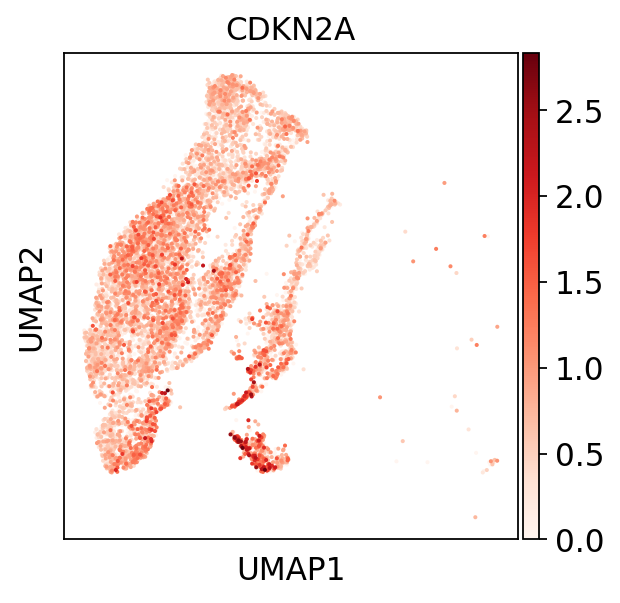

In [11]:
adata2b = adata[adata.obs['exp'].isin(['WT'])]
sc.pl.umap(adata2b, color=['CDKN2A'], color_map='Reds', use_raw=False)


In [12]:
try1= sc.get.obs_df(
    adata2b,
    keys=['CDKN2A']
)
try1.max()

CDKN2A    2.83405
dtype: float32

/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


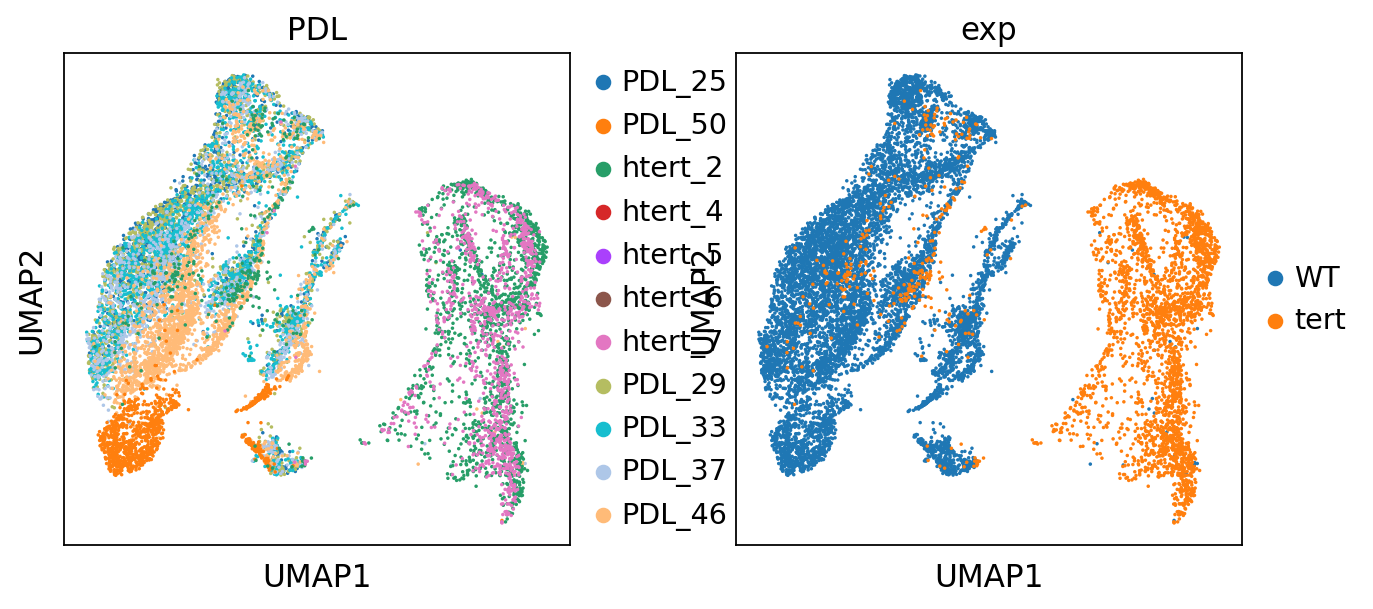

In [13]:
sc.pl.umap(adata, color=['PDL', 'exp'])


/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1171: FutureWarning: In a future version of pandas all arguments of Categorical.replace except for the argument 'value' will be keyword-only.
  values = values.replace(values.categories.difference(groups), np.nan)
/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1171: FutureWarning: Categorical.replace is deprecated and will be removed in a future version. Use Series.replace directly instead.
  values = values.replace(values.categories.difference(groups), np.nan)
/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


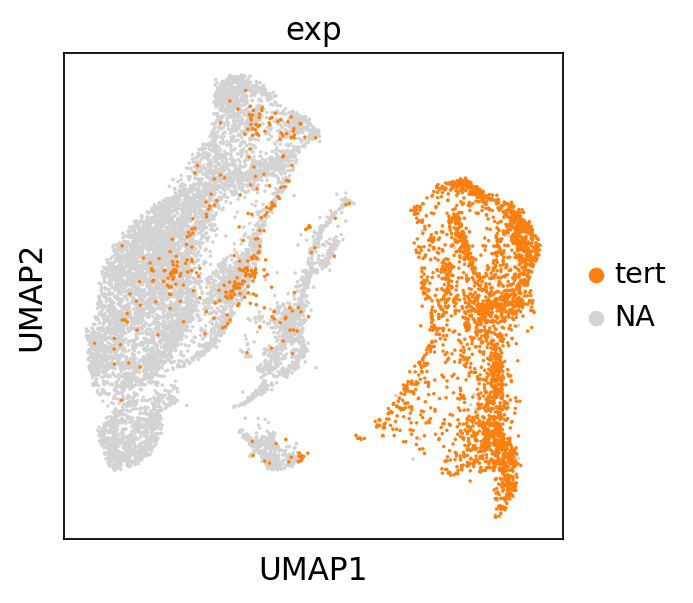

In [14]:
sc.pl.umap(adata, color=['exp'], groups='tert')


/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1171: FutureWarning: In a future version of pandas all arguments of Categorical.replace except for the argument 'value' will be keyword-only.
  values = values.replace(values.categories.difference(groups), np.nan)
/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1171: FutureWarning: Categorical.replace is deprecated and will be removed in a future version. Use Series.replace directly instead.
  values = values.replace(values.categories.difference(groups), np.nan)
/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


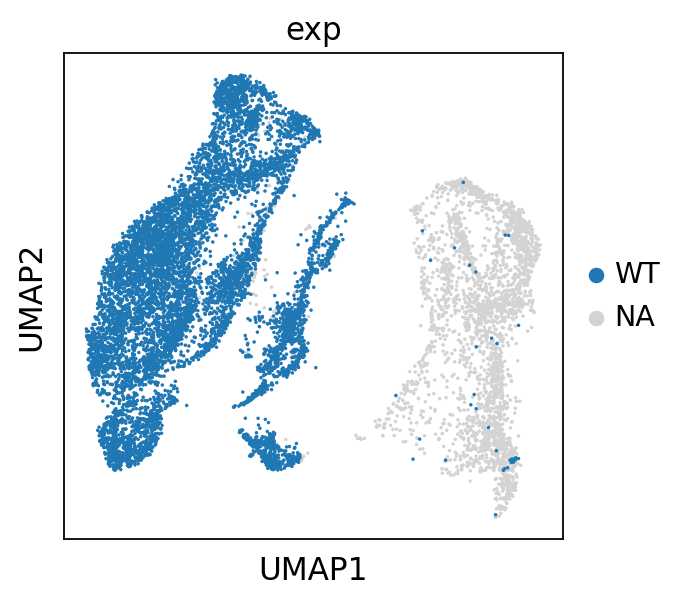

In [15]:
sc.pl.umap(adata, color=['exp'], groups='WT')


/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value
/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


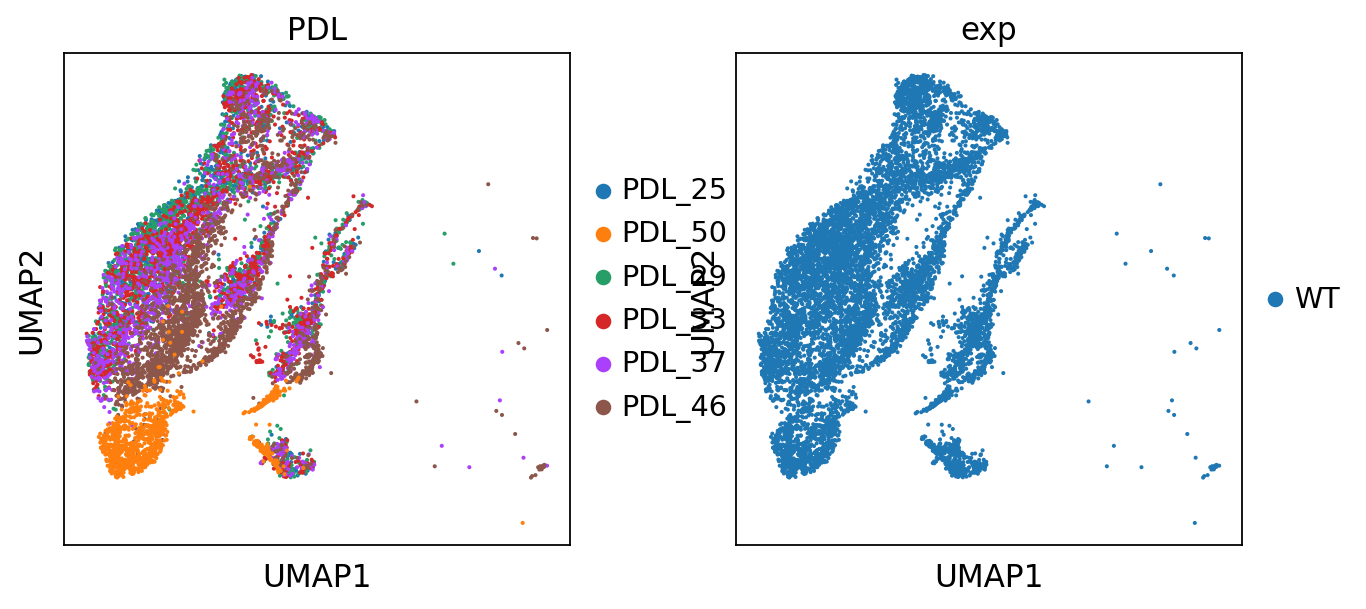

In [16]:
sc.pl.umap(adata2, color=['PDL', 'exp'])


In [17]:
sc.pp.neighbors(adata2)

sc.tl.umap(adata2)


computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:12)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:19)


/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


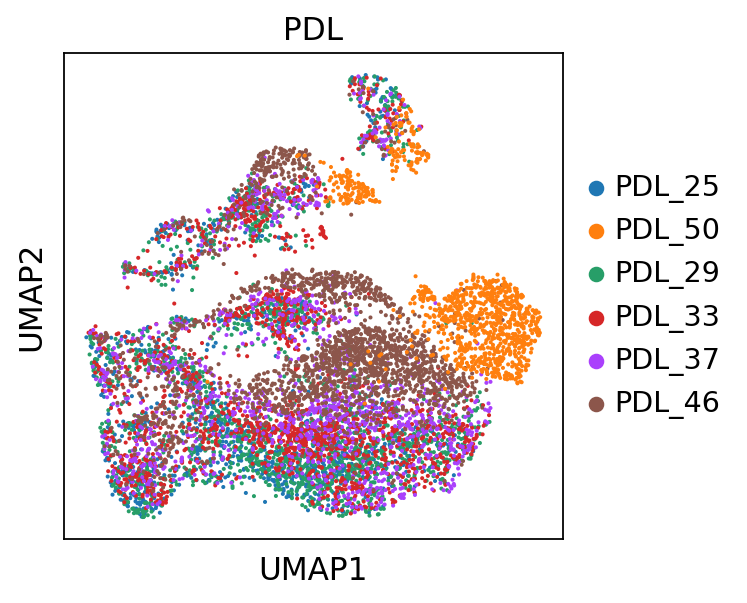

In [18]:
sc.pl.umap(adata2, color=['PDL'])


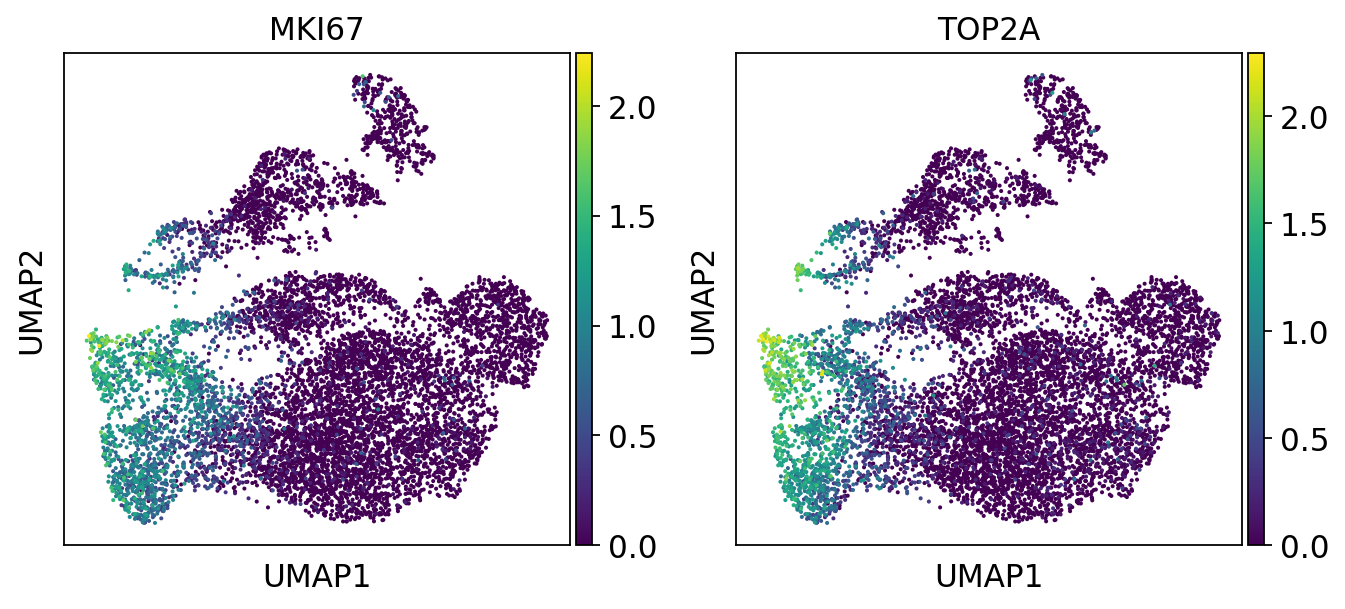

In [19]:
sc.pl.umap(adata2, color=['MKI67', 'TOP2A'])

In [20]:
fromNeva=pd.read_csv('/seq/epiprod02/etorlait/p16/From_Neva/Hayflick_Data/Hayflick_metadata.tsv', sep=' ')

In [21]:
adata.obs['p16']=fromNeva['p16']
adata.obs['p14']=fromNeva['p14']
adata.obs['p16.norm']=fromNeva['p16.norm']
adata.obs['p14.norm']=fromNeva['p14.norm']

In [22]:
adata2.obs['p16']=fromNeva['p16']
adata2.obs['p14']=fromNeva['p14']
adata2.obs['p16.norm']=fromNeva['p16.norm']
adata2.obs['p14.norm']=fromNeva['p14.norm']

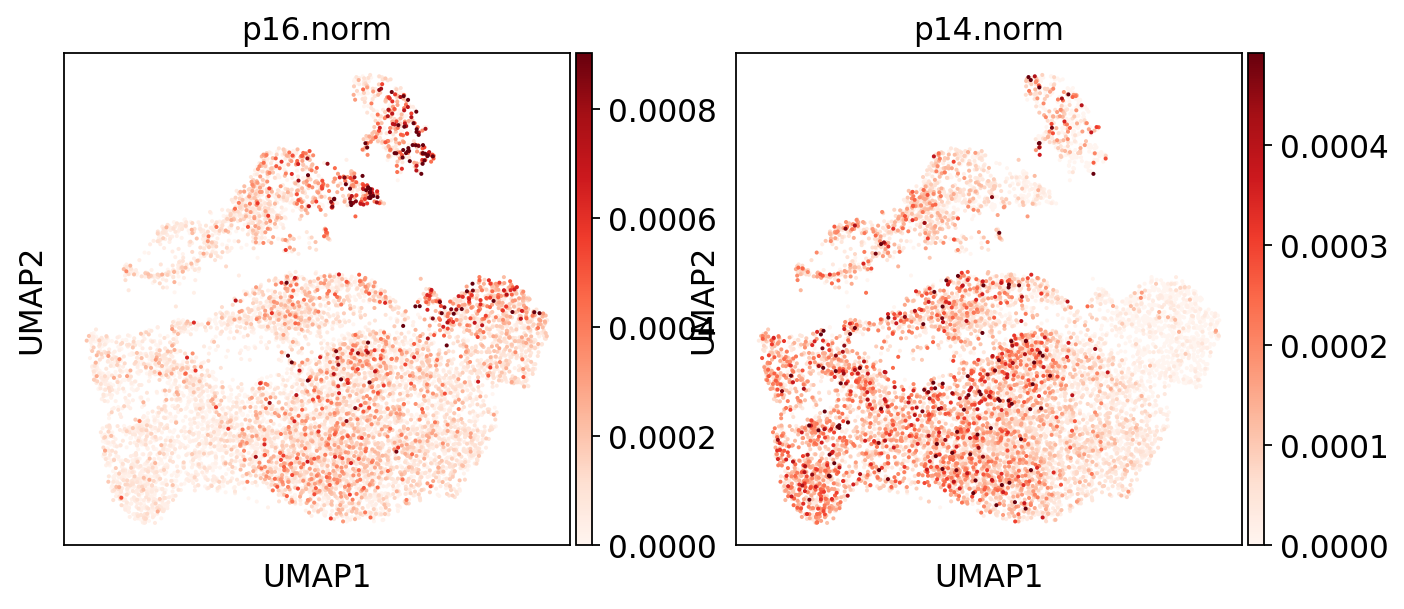

In [23]:
sc.pl.umap(adata2, color=['p16.norm', 'p14.norm'], color_map='Reds', vmax='p99.25')


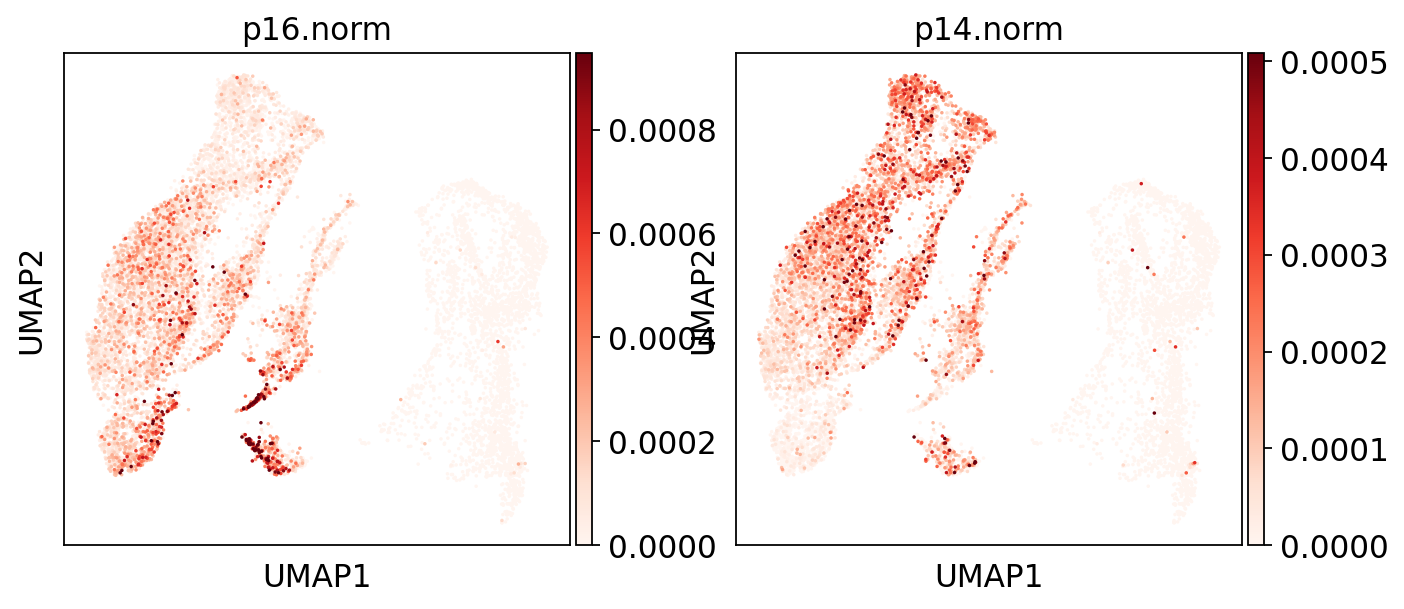

In [24]:
sc.pl.umap(adata, color=['p16.norm', 'p14.norm'], color_map='Reds', vmax='p99.5')


In [25]:
adata2

AnnData object with n_obs × n_vars = 8953 × 33538
    obs: 'nCount_RNA', 'nFeature_RNA', 'barcode', 'PDL', 'sample', 'exp', 'S.Score', 'G2M.Score', 'Phase', 'nCount_SCT', 'nFeature_SCT', 'p16', 'p14', 'p16.norm', 'p14.norm'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    uns: 'PDL_colors', 'exp_colors', 'neighbors', 'umap'
    obsm: 'X_mpcs', 'X_pca', 'X_rna_pcs_2kv', 'X_s_sct_pcs_s3_hay_d', 'X_umap'
    obsp: 'distances', 'connectivities'

In [26]:
fromDave=pd.read_csv('/seq/epiprod02/etorlait/p16/Published_Data/Chan_et_al_2022_eLife/scRNAseq/from_Dave/hay_ps_data.txt', sep='\t', index_col=0)

In [27]:
adata3 = adata2[fromDave.index]

In [28]:
adata3

View of AnnData object with n_obs × n_vars = 7489 × 33538
    obs: 'nCount_RNA', 'nFeature_RNA', 'barcode', 'PDL', 'sample', 'exp', 'S.Score', 'G2M.Score', 'Phase', 'nCount_SCT', 'nFeature_SCT', 'p16', 'p14', 'p16.norm', 'p14.norm'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    uns: 'PDL_colors', 'exp_colors', 'neighbors', 'umap'
    obsm: 'X_mpcs', 'X_pca', 'X_rna_pcs_2kv', 'X_s_sct_pcs_s3_hay_d', 'X_umap'
    obsp: 'distances', 'connectivities'

In [29]:
adata2.obs['pstime']=fromDave['pseudotime']

In [30]:
adata3.obs['pstime']=fromDave['pseudotime']

/local/scratch/53021431.1.broad/ipykernel_44670/4043373073.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata3.obs['pstime']=fromDave['pseudotime']


In [31]:
adata2.obs

,nCount_RNA,nFeature_RNA,barcode,PDL,sample,exp,S.Score,G2M.Score,Phase,nCount_SCT,nFeature_SCT,p16,p14,p16.norm,p14.norm,pstime
AAACGGGAGAGAACAG-1,34927.0,5474,AAACGGGAGAGAACAG-1,PDL_25,1,WT,0.541781,0.209151,S,35623.0,5474,0,3,0.000000,0.000086,0.116258
AAACGGGGTTTAAGCC-1,35166.0,5426,AAACGGGGTTTAAGCC-1,PDL_25,1,WT,0.404641,0.513172,G2M,35723.0,5426,0,5,0.000000,0.000142,1.266756
AAACGGGTCCTCATTA-1,36444.0,5749,AAACGGGTCCTCATTA-1,PDL_25,1,WT,-0.009645,0.473208,G2M,36291.0,5748,1,2,0.000027,0.000055,4.245586
AAACGGGTCTAAGCCA-1,67652.0,6885,AAACGGGTCTAAGCCA-1,PDL_25,1,WT,-0.272565,-0.505199,G1,37575.0,6022,8,9,0.000118,0.000133,18.990912
AAACGGGTCTGAGGGA-1,7680.0,1920,AAACGGGTCTGAGGGA-1,PDL_25,1,WT,0.347032,0.027671,S,32182.0,4066,0,0,0.000000,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGCGCGTACAAGTA-11,34690.0,5407,TTTGCGCGTACAAGTA-11,PDL_50,11,WT,-0.148770,-0.503520,G1,35565.0,5405,9,0,0.000259,0.000000,22.441066
TTTGCGCTCAGCTGGC-11,47249.0,6599,TTTGCGCTCAGCTGGC-11,PDL_50,11,WT,-0.320614,-0.515671,G1,37513.0,6571,6,3,0.000127,0.000063,22.078077
TTTGTCAAGAATGTTG-11,94455.0,7557,TTTGTCAAGAATGTTG-11,PDL_50,11,WT,-0.251967,-0.460960,G1,38529.0,5412,116,4,0.001228,0.000042,NaN
TTTGTCACATCGGAAG-11,50085.0,6439,TTTGTCACATCGGAAG-11,PDL_50,11,WT,-0.323176,-0.545851,G1,37512.0,6351,9,0,0.000180,0.000000,22.441066


In [32]:
adata3.obs

,nCount_RNA,nFeature_RNA,barcode,PDL,sample,exp,S.Score,G2M.Score,Phase,nCount_SCT,nFeature_SCT,p16,p14,p16.norm,p14.norm,pstime
AAACGGGAGAGAACAG-1,34927.0,5474,AAACGGGAGAGAACAG-1,PDL_25,1,WT,0.541781,0.209151,S,35623.0,5474,0,3,0.000000,0.000086,0.116258
AAACGGGGTTTAAGCC-1,35166.0,5426,AAACGGGGTTTAAGCC-1,PDL_25,1,WT,0.404641,0.513172,G2M,35723.0,5426,0,5,0.000000,0.000142,1.266756
AAACGGGTCCTCATTA-1,36444.0,5749,AAACGGGTCCTCATTA-1,PDL_25,1,WT,-0.009645,0.473208,G2M,36291.0,5748,1,2,0.000027,0.000055,4.245586
AAACGGGTCTAAGCCA-1,67652.0,6885,AAACGGGTCTAAGCCA-1,PDL_25,1,WT,-0.272565,-0.505199,G1,37575.0,6022,8,9,0.000118,0.000133,18.990912
AAAGATGCAGTGAGTG-1,34468.0,5156,AAAGATGCAGTGAGTG-1,PDL_25,1,WT,-0.122336,-0.475623,G1,35547.0,5156,11,2,0.000319,0.000058,12.590782
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTCCTCTCACCCGAG-11,88858.0,8182,TTTCCTCTCACCCGAG-11,PDL_50,11,WT,-0.338690,-0.547881,G1,38441.0,6436,10,3,0.000113,0.000034,22.441066
TTTCCTCTCCAGAAGG-11,91679.0,7155,TTTCCTCTCCAGAAGG-11,PDL_50,11,WT,-0.226797,-0.348823,G1,36985.0,4883,8,3,0.000087,0.000033,21.823418
TTTGCGCGTACAAGTA-11,34690.0,5407,TTTGCGCGTACAAGTA-11,PDL_50,11,WT,-0.148770,-0.503520,G1,35565.0,5405,9,0,0.000259,0.000000,22.441066
TTTGCGCTCAGCTGGC-11,47249.0,6599,TTTGCGCTCAGCTGGC-11,PDL_50,11,WT,-0.320614,-0.515671,G1,37513.0,6571,6,3,0.000127,0.000063,22.078077


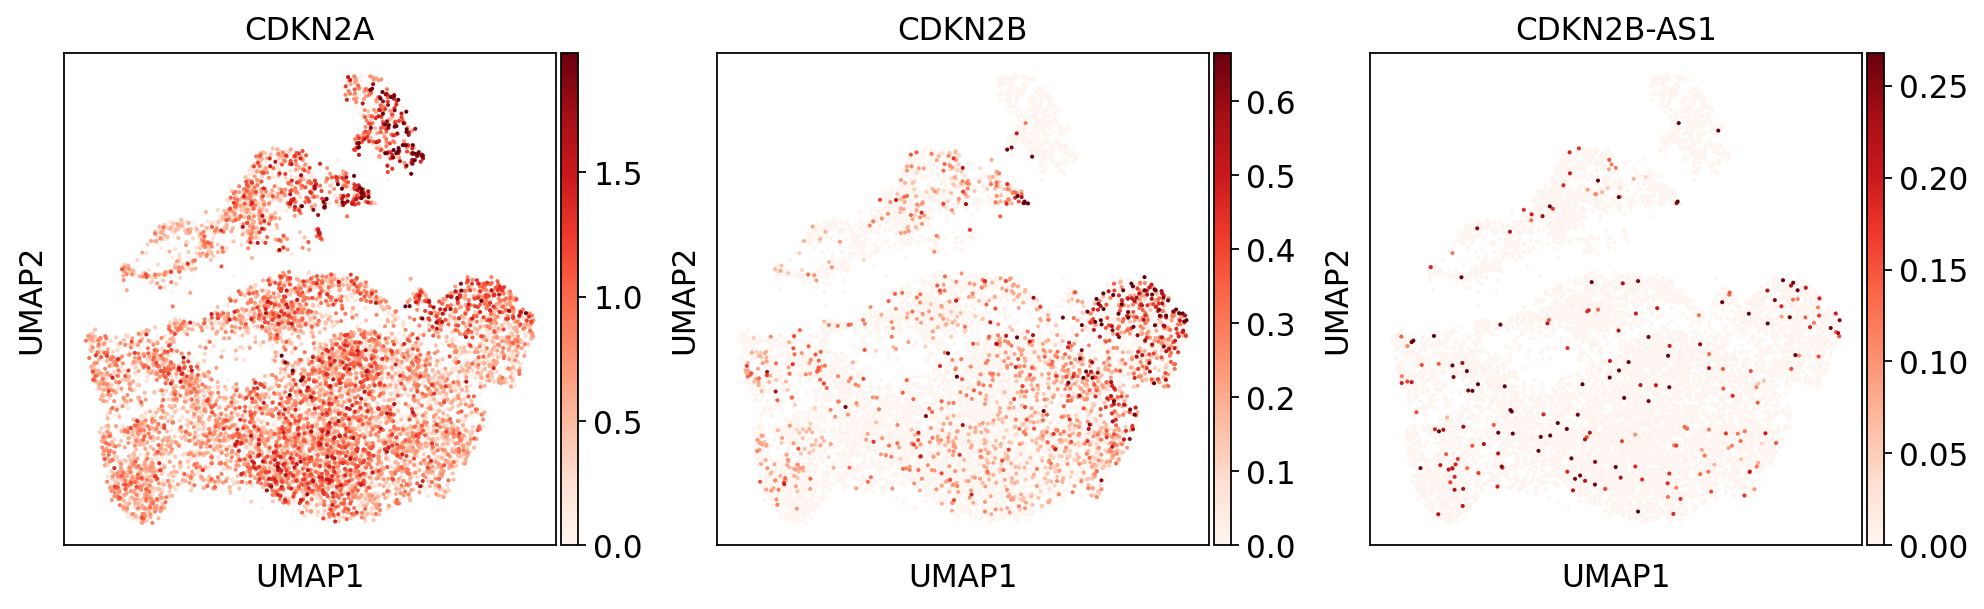

In [33]:
sc.pl.umap(adata2, color=['CDKN2A', 'CDKN2B', 'CDKN2B-AS1'], color_map='Reds', vmax='p99.5')


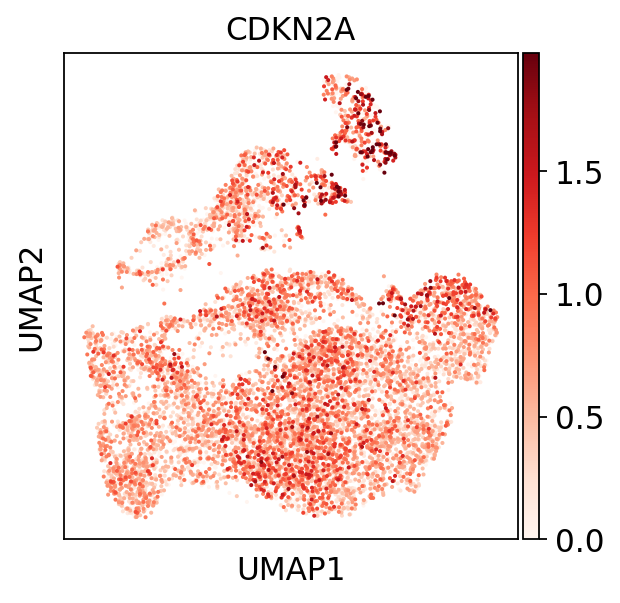

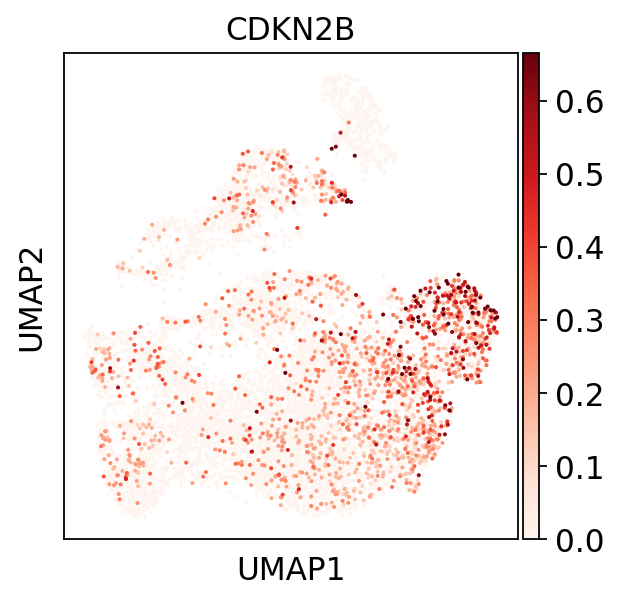

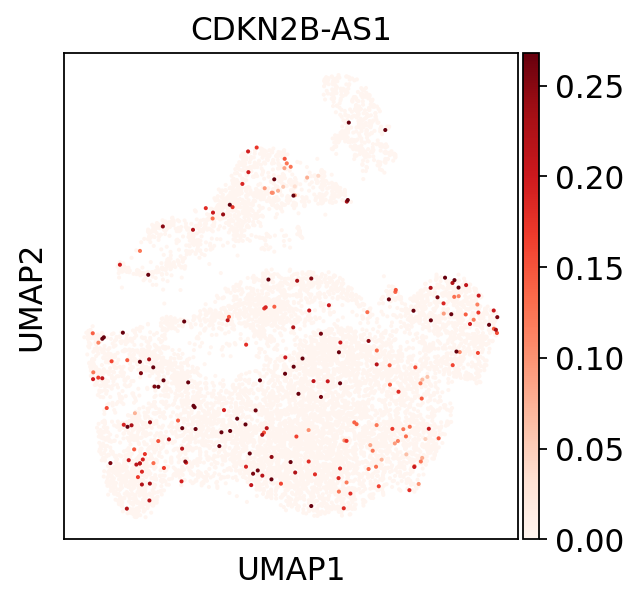

In [34]:
sc.pl.umap(adata2, color=['CDKN2A'], color_map='Reds', vmax='p99.5')
sc.pl.umap(adata2, color=['CDKN2B'], color_map='Reds', vmax='p99.5')
sc.pl.umap(adata2, color=['CDKN2B-AS1'], color_map='Reds', vmax='p99.5')


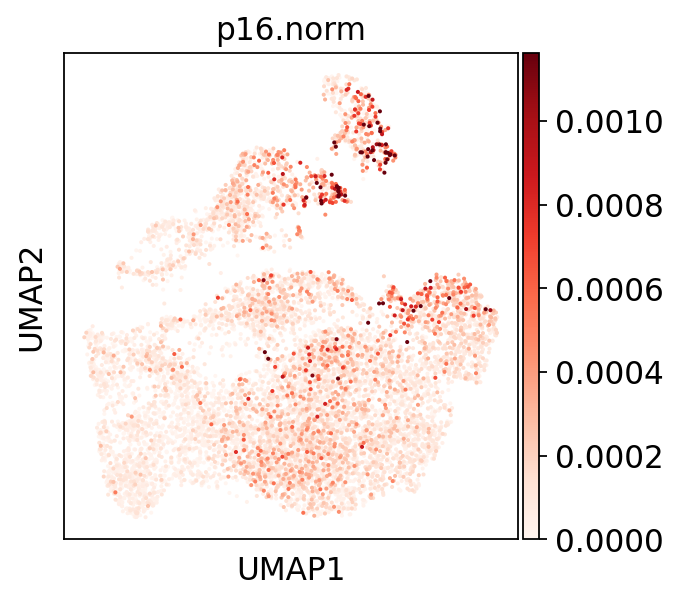

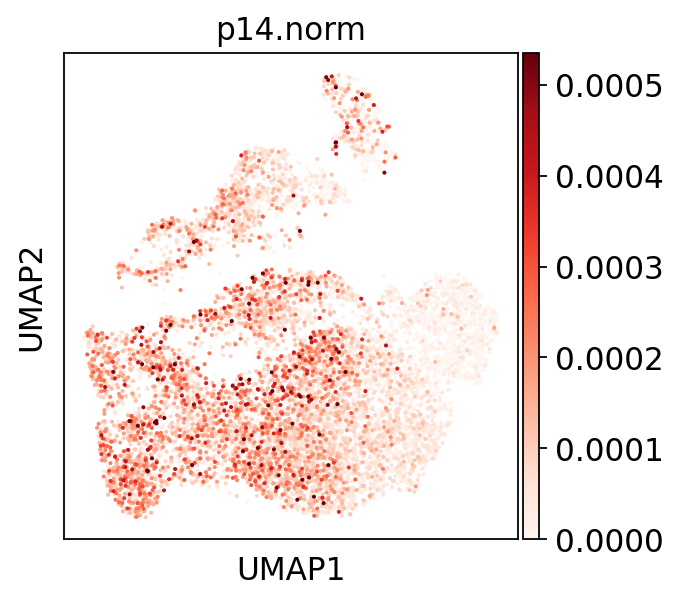

In [35]:
sc.pl.umap(adata2, color=['p16.norm'], color_map='Reds', vmax='p99.5')
sc.pl.umap(adata2, color=['p14.norm'], color_map='Reds', vmax='p99.5')

In [36]:
try2= sc.get.obs_df(
    adata2,
    keys=['CDKN2A']
)
try2.max()

CDKN2A    2.83405
dtype: float32

In [37]:
adata2.obs.PDL

AAACGGGAGAGAACAG-1     PDL_25
AAACGGGGTTTAAGCC-1     PDL_25
AAACGGGTCCTCATTA-1     PDL_25
AAACGGGTCTAAGCCA-1     PDL_25
AAACGGGTCTGAGGGA-1     PDL_25
                        ...  
TTTGCGCGTACAAGTA-11    PDL_50
TTTGCGCTCAGCTGGC-11    PDL_50
TTTGTCAAGAATGTTG-11    PDL_50
TTTGTCACATCGGAAG-11    PDL_50
TTTGTCATCGAGAGCA-11    PDL_50
Name: PDL, Length: 8953, dtype: category
Categories (6, object): ['PDL_25', 'PDL_50', 'PDL_29', 'PDL_33', 'PDL_37', 'PDL_46']

In [38]:
adata2.obs.PDL=adata2.obs.PDL.cat.reorder_categories(['PDL_25', 'PDL_29', 'PDL_33', 'PDL_37', 'PDL_46', 'PDL_50'], ordered=True)

In [39]:
adata2.obs.PDL

AAACGGGAGAGAACAG-1     PDL_25
AAACGGGGTTTAAGCC-1     PDL_25
AAACGGGTCCTCATTA-1     PDL_25
AAACGGGTCTAAGCCA-1     PDL_25
AAACGGGTCTGAGGGA-1     PDL_25
                        ...  
TTTGCGCGTACAAGTA-11    PDL_50
TTTGCGCTCAGCTGGC-11    PDL_50
TTTGTCAAGAATGTTG-11    PDL_50
TTTGTCACATCGGAAG-11    PDL_50
TTTGTCATCGAGAGCA-11    PDL_50
Name: PDL, Length: 8953, dtype: category
Categories (6, object): ['PDL_25' < 'PDL_29' < 'PDL_33' < 'PDL_37' < 'PDL_46' < 'PDL_50']

/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


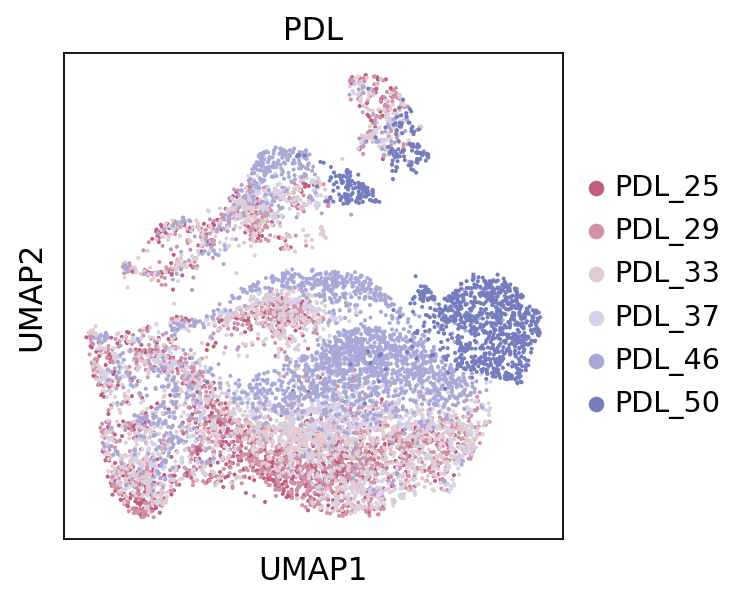

In [40]:
sc.pl.umap(adata2, color=['PDL'], palette=['#C15D80','#D191A7', '#E1CAD1', '#D5D2E9', '#A9A9D8', '#747DBF'],
            #order=['PDL_25', 'PDL_29', 'PDL_33', 'PDL_37', 'PDL_46', 'PDL_50']
          )

In [41]:
#SenMayo genes from Saul et al Nat Comm 2022
senmayo = ['ACVR1B', 'ANG', 'ANGPT1', 'ANGPTL4', 'AREG', 'AXL', 'BEX3', 'BMP2', 'BMP6', 'C3', 'CCL1', 'CCL13', 'CCL16', 'CCL2', 'CCL20', 'CCL24', 'CCL26', 'CCL3', 'CCL3L1', 'CCL4', 'CCL5', 'CCL7', 'CCL8', 'CD55', 'CD9', 'CSF1', 'CSF2', 'CSF2RB', 'CST4', 'CTNNB1', 'CTSB', 'CXCL1', 'CXCL10', 'CXCL12', 'CXCL16', 'CXCL2', 'CXCL3', 'CXCL8', 'CXCR2', 'DKK1', 'EDN1', 'EGF', 'EGFR', 'EREG', 'ESM1', 'ETS2', 'FAS', 'FGF1', 'FGF2', 'FGF7', 'GDF15', 'GEM', 'GMFG', 'HGF', 'HMGB1', 'ICAM1', 'ICAM3', 'IGF1', 'IGFBP1', 'IGFBP2', 'IGFBP3', 'IGFBP4', 'IGFBP5', 'IGFBP6', 'IGFBP7', 'IL10', 'IL13', 'IL15', 'IL18', 'IL1A', 'IL1B', 'IL2', 'IL32', 'IL6', 'IL6ST', 'IL7', 'INHA', 'IQGAP2', 'ITGA2', 'ITPKA', 'JUN', 'KITLG', 'LCP1', 'MIF', 'MMP1', 'MMP10', 'MMP12', 'MMP13', 'MMP14', 'MMP2', 'MMP3', 'MMP9', 'NAP1L4', 'NRG1', 'PAPPA', 'PECAM1', 'PGF', 'PIGF', 'PLAT', 'PLAU', 'PLAUR', 'PTBP1', 'PTGER2', 'PTGES', 'RPS6KA5', 'SCAMP4', 'SELPLG', 'SEMA3F', 'SERPINB4', 'SERPINE1', 'SERPINE2', 'SPP1', 'SPX', 'TIMP2', 'TNF', 'TNFRSF10C', 'TNFRSF11B', 'TNFRSF1A', 'TNFRSF1B', 'TUBGCP2', 'VEGFA', 'VEGFC', 'VGF', 'WNT16', 'WNT2']
sc.tl.score_genes(adata2, senmayo, score_name='senmayo')

computing score 'senmayo'
    finished: added
    'senmayo', score of gene set (adata.obs).
    898 total control genes are used. (0:00:00)


/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/tools/_score_genes.py:151: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  for cut in np.unique(obs_cut.loc[gene_list]):


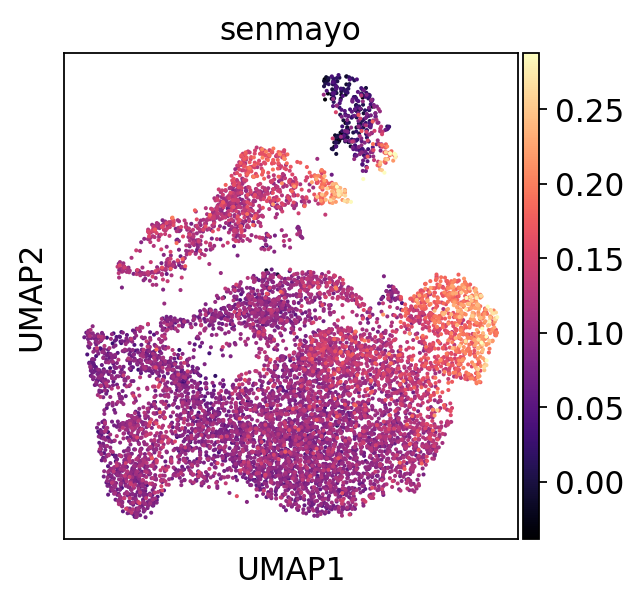

In [42]:
sc.pl.umap(adata2, color=['senmayo'], color_map='magma', vmax='p99.9')

In [43]:
#SASP genes are secreted genes from SenMayo genes from Saul et al Nat Comm 2022, Suppl table
sasp=['ANG', 'ANGPT1', 'ANGPTL4', 'BMP2', 'BMP6', 'C3', 'CCL1', 'CCL13', 'CCL16', 'CCL2', 'CCL20', 'CCL24', 'CCL26', 'CCL3', 'CCL3L1', 'CCL4', 'CCL5', 'CCL7', 'CCL8', 'CD55', 'CSF1', 'CSF2', 'CST4', 'CTSB', 'CXCL1', 'CXCL10', 'CXCL12', 'CXCL16', 'CXCL2', 'CXCL3', 'CXCL8', 'DKK1', 'EDN1', 'EREG', 'ESM1', 'FGF1', 'FGF2', 'FGF7', 'GDF15', 'HGF', 'IGF1', 'IGFBP1', 'IGFBP2', 'IGFBP3', 'IGFBP4', 'IGFBP5', 'IGFBP6', 'IGFBP7', 'IL10', 'IL13', 'IL15', 'IL18', 'IL1A', 'IL1B', 'IL2', 'IL32', 'IL6', 'IL7', 'INHA', 'MIF', 'MMP1', 'MMP10', 'MMP12', 'MMP13', 'MMP2', 'MMP3', 'MMP9', 'NRG1', 'PAPPA', 'PGF', 'PLAT', 'PLAU', 'SEMA3F', 'SERPINE1', 'SERPINE2', 'SPP1', 'SPX', 'TIMP2', 'TNF', 'VEGFA', 'VEGFC', 'VGF', 'WNT16']
sc.tl.score_genes(adata2, sasp, score_name='sasp')

computing score 'sasp'
    finished: added
    'sasp', score of gene set (adata.obs).
    899 total control genes are used. (0:00:00)


/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/tools/_score_genes.py:151: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  for cut in np.unique(obs_cut.loc[gene_list]):


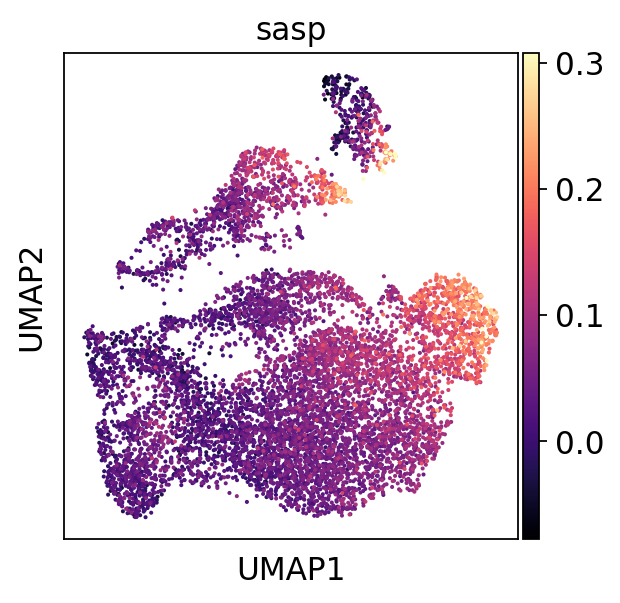

In [44]:
sc.pl.umap(adata2, color=['sasp'], color_map='magma', vmax='p99.9')

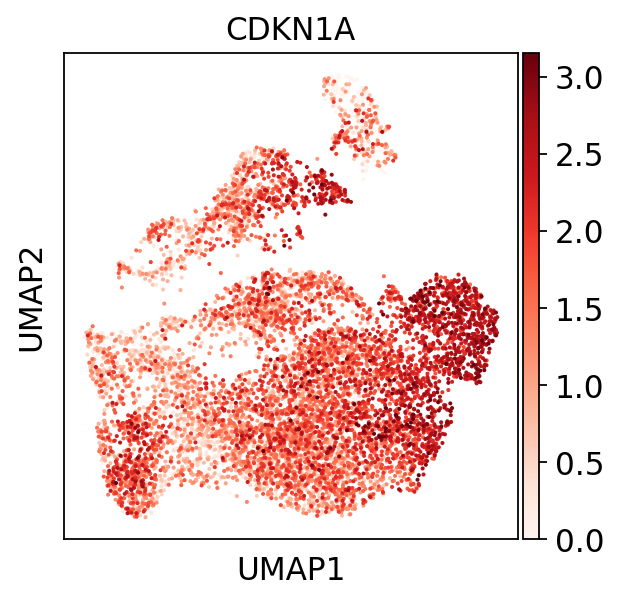

In [45]:
sc.pl.umap(adata2, color=['CDKN1A'], color_map='Reds', vmax='p99.5')

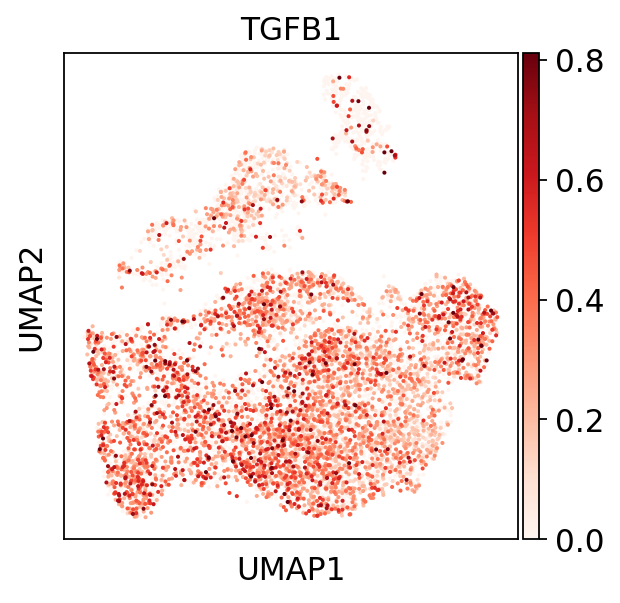

In [46]:
sc.pl.umap(adata2, color=['TGFB1'], color_map='Reds', vmax='p99.5')

In [48]:
p16_top200=pd.read_csv('/seq/epiprod02/etorlait/p16/Published_Data/Chan_et_al_2022_eLife/scRNAseq/HVG_Corr_Top203_genes/HVG_correlation_matrix_hayflick_p16_norm_top200_pearson_corr_genes_excl_p16_CDKN2A.txt', sep='\t', index_col=0)
p16_top200

,p16.norm
IGFBP7,0.308232
DYNLT3,0.276190
TIMP1,0.257599
ATP6V1G1,0.252060
HIST1H1C,0.245991
...,...
GSN,0.092363
FIBIN,0.091267
MOSPD1,0.090972
APLP1,0.090899


In [73]:
## Actual 200 genes (excluding p16 and CDKN2A)

In [49]:
list(p16_top200.index)

['IGFBP7',
 'DYNLT3',
 'TIMP1',
 'ATP6V1G1',
 'HIST1H1C',
 'UCHL1',
 'LUM',
 'MYL9',
 'SERPINE2',
 'TGFBI',
 'HSPB1',
 'RABAC1',
 'PERP',
 'TPM2',
 'SRP14',
 'SERF2',
 'HIST1H4H',
 'HIST1H2AC',
 'ATP6V0E1',
 'CCND2',
 'NPC2',
 'ARF4',
 'HSPB6',
 'IGFBP4',
 'GPX3',
 'ATP6V1E1',
 'ATP6V1F',
 'NPDC1',
 'SAT1',
 'TMEM59',
 'SDCBP',
 'PRDX6',
 'GRN',
 'LINC02154',
 'HIST1H2BC',
 'RSU1',
 'MAP3K7CL',
 'SELENOW',
 'MGST1',
 'PSAP',
 'IFI6',
 'DKK3',
 'TMEM159',
 'SARAF',
 'DPP4',
 'ANKRD1',
 'MAP1LC3A',
 'ASAH1',
 'AK3',
 'CYTL1',
 'ATP5IF1',
 'PEA15',
 'GAS6',
 'CYB5R1',
 'NNMT',
 'UBB',
 'LRPAP1',
 'UBL5',
 'CSTB',
 'MFGE8',
 'CALB2',
 'S100A13',
 'PRDX1',
 'CYB5R3',
 'SERINC2',
 'PPP2R1A',
 'BNIP3L',
 'EGFL7',
 'PKM',
 'PRDX2',
 'TXNIP',
 'TAGLN',
 'ANXA5',
 'ANTXR1',
 'GABARAPL1',
 'GSTM3',
 'HLA-C',
 'CYSTM1',
 'GSTP1',
 'HSD17B14',
 'UQCR11',
 'CADM1',
 'KCNJ2',
 'ETHE1',
 'BCAP31',
 'PRPS1',
 'MYOZ2',
 'PSG9',
 'C15orf48',
 'YPEL5',
 'C9orf16',
 'EPAS1',
 'PLXDC2',
 'C5orf46',
 'NDUFA1

computing score 'high_corr_p16_norm_genes'
    finished: added
    'high_corr_p16_norm_genes', score of gene set (adata.obs).
    543 total control genes are used. (0:00:00)


/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/tools/_score_genes.py:151: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  for cut in np.unique(obs_cut.loc[gene_list]):


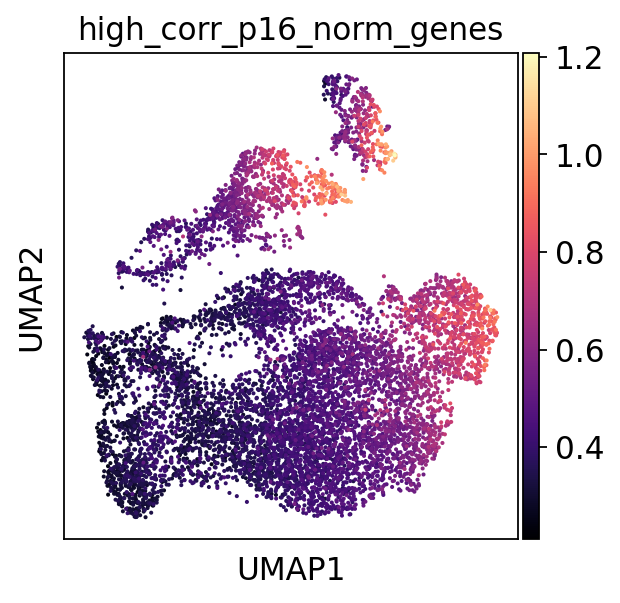

In [50]:
sc.tl.score_genes(adata2, list(p16_top200.index), score_name='high_corr_p16_norm_genes')
sc.pl.umap(adata2, color=['high_corr_p16_norm_genes' ], color_map='magma')

In [51]:
# p14 genes had the same problem as above - solved in this iteration

In [52]:
p14_top200=pd.read_csv('/seq/epiprod02/etorlait/p16/Published_Data/Chan_et_al_2022_eLife/scRNAseq/HVG_Corr_Top203_genes/HVG_correlation_matrix_hayflick_p14_norm_top200_pearson_corr_genes_excl_p14_CDKN2A.txt', sep='\t', index_col=0)
list(p14_top200.index)

['H2AFZ',
 'HMGB1',
 'HMGN2',
 'PCLAF',
 'CENPW',
 'TK1',
 'TMSB15A',
 'RPL39L',
 'DEK',
 'BIRC5',
 'STMN1',
 'PTTG1',
 'CENPN',
 'HIST1H4C',
 'CDKN3',
 'MYL6',
 'CKS1B',
 'CENPM',
 'MALAT1',
 'TYMS',
 'PHF19',
 'RRM2',
 'SMC4',
 'HMGB3',
 'DHFR',
 'PIMREG',
 'FOXM1',
 'ZWINT',
 'H2AFX',
 'HMGB2',
 'TROAP',
 'TPX2',
 'GINS2',
 'UBE2T',
 'CENPF',
 'MKI67',
 'CKS2',
 'CENPU',
 'ITGB3BP',
 'CDCA3',
 'NUSAP1',
 'TMPO',
 'ADAMTS6',
 'GTSE1',
 'ANLN',
 'UBE2C',
 'NRGN',
 'ODC1',
 'FOSL1',
 'USP1',
 'DNAJC9',
 'CLSPN',
 'UBE2S',
 'TOP2A',
 'PBK',
 'CENPK',
 'MZT1',
 'CDKN2C',
 'CEP55',
 'MYBL2',
 'EZH2',
 'DLEU2',
 'GMNN',
 'AURKB',
 'MIS18BP1',
 'PLAUR',
 'TEX30',
 'SHCBP1',
 'TCF19',
 'HELLS',
 'RAD51AP1',
 'NSD2',
 'CCDC34',
 'ASF1B',
 'ANP32E',
 'FBXO5',
 'CENPA',
 'CCNA2',
 'ASPM',
 'MELK',
 'CDC20',
 'NETO2',
 'DLGAP5',
 'MAD2L1',
 'CCNB1',
 'SGO1',
 'SPC25',
 'TUBB4B',
 'DBF4',
 'SOCS2',
 'UHRF1',
 'PSMC3IP',
 'PCOLCE',
 'DEPDC1',
 'MND1',
 'KIF20B',
 'SKA3',
 'GPSM2',
 'CDCA5',
 'ATP5

computing score 'high_corr_p14_norm_genes'
    finished: added
    'high_corr_p14_norm_genes', score of gene set (adata.obs).
    397 total control genes are used. (0:00:00)


/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/tools/_score_genes.py:151: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  for cut in np.unique(obs_cut.loc[gene_list]):


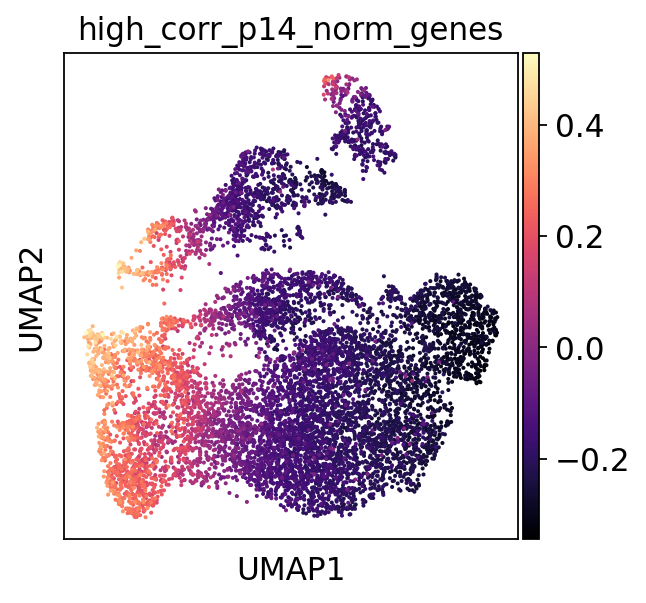

In [53]:
sc.tl.score_genes(adata2, list(p14_top200.index), score_name='high_corr_p14_norm_genes')
sc.pl.umap(adata2, color=['high_corr_p14_norm_genes' ], color_map='magma')

In [54]:
CDKN2B_top200=pd.read_csv('/seq/epiprod02/etorlait/p16/Published_Data/Chan_et_al_2022_eLife/scRNAseq/HVG_Corr_Top203_genes/HVG_correlation_matrix_hayflick_CDKN2B_top200_pearson_corr_genes_excl_CDKN2B.txt', sep='\t', index_col=0)
CDKN2B_top200

,CDKN2B
DPP4,0.353527
TGFBI,0.346318
EPAS1,0.331964
PAPPA,0.325292
PLXDC2,0.316374
...,...
STK32B,0.198770
C9orf3,0.198397
SPOCK1,0.197637
FRMD6,0.197542


computing score 'high_corr_CDKN2B_genes'
    finished: added
    'high_corr_CDKN2B_genes', score of gene set (adata.obs).
    496 total control genes are used. (0:00:00)


/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/tools/_score_genes.py:151: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  for cut in np.unique(obs_cut.loc[gene_list]):


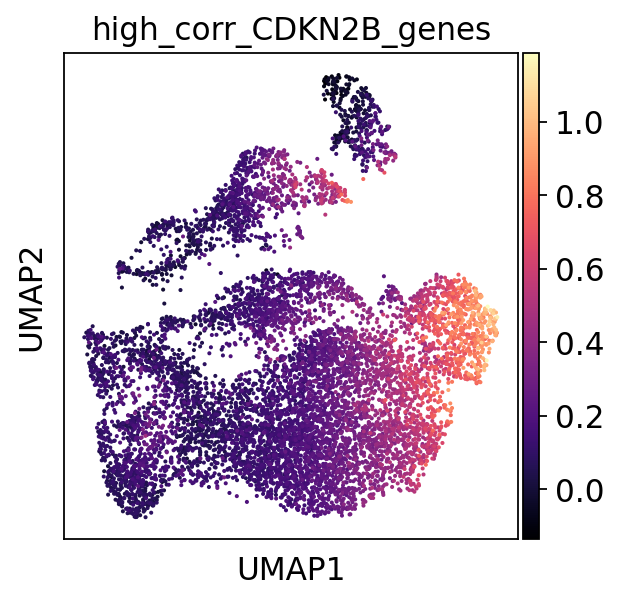

In [55]:
sc.tl.score_genes(adata2, list(CDKN2B_top200.index), score_name='high_corr_CDKN2B_genes')
sc.pl.umap(adata2, color=['high_corr_CDKN2B_genes' ], color_map='magma')

In [56]:
adata3 = adata2[fromDave.index]

In [57]:
adata3

View of AnnData object with n_obs × n_vars = 7489 × 33538
    obs: 'nCount_RNA', 'nFeature_RNA', 'barcode', 'PDL', 'sample', 'exp', 'S.Score', 'G2M.Score', 'Phase', 'nCount_SCT', 'nFeature_SCT', 'p16', 'p14', 'p16.norm', 'p14.norm', 'pstime', 'senmayo', 'sasp', 'high_corr_p16_norm_genes', 'high_corr_p14_norm_genes', 'high_corr_CDKN2B_genes'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable'
    uns: 'PDL_colors', 'exp_colors', 'neighbors', 'umap'
    obsm: 'X_mpcs', 'X_pca', 'X_rna_pcs_2kv', 'X_s_sct_pcs_s3_hay_d', 'X_umap'
    obsp: 'distances', 'connectivities'

In [58]:
for_heatmap_new= sc.get.obs_df(
    adata3,
    keys=['sample', 'exp', 'PDL','Phase',
          'p16', 'p14', 'p16.norm', 'p14.norm','CDKN2A', 'CDKN2B', 'CDKN2B-AS1',
          'pstime', 'senmayo', 'sasp', 
          'MKI67','TOP2A','CDKN1A', 'TGFB1',
          'high_corr_p16_norm_genes', 'high_corr_p14_norm_genes', 'high_corr_CDKN2B_genes']
)

In [59]:
for_heatmap_new

,sample,exp,PDL,Phase,p16,p14,p16.norm,p14.norm,CDKN2A,CDKN2B,...,pstime,senmayo,sasp,MKI67,TOP2A,CDKN1A,TGFB1,high_corr_p16_norm_genes,high_corr_p14_norm_genes,high_corr_CDKN2B_genes
AAACGGGAGAGAACAG-1,1,WT,PDL_25,S,0,3,0.000000,0.000086,0.251779,0.000000,...,0.116258,0.063867,0.006708,0.888532,0.251779,0.452745,0.000000,0.310500,0.153775,0.061552
AAACGGGGTTTAAGCC-1,1,WT,PDL_25,G2M,0,5,0.000000,0.000142,0.450267,0.000000,...,1.266756,0.084847,0.023680,0.995543,0.450267,2.468599,0.000000,0.363641,0.207352,0.108748
AAACGGGTCCTCATTA-1,1,WT,PDL_25,G2M,1,2,0.000027,0.000055,0.437472,0.000000,...,4.245586,0.079321,0.017887,0.973186,0.600583,0.600583,0.242470,0.422600,0.143261,0.214340
AAACGGGTCTAAGCCA-1,1,WT,PDL_25,G1,8,9,0.000118,0.000133,0.710352,0.000000,...,18.990912,0.080022,0.046346,0.000000,0.137860,1.337233,0.000000,0.473145,-0.208634,0.355893
AAAGATGCAGTGAGTG-1,1,WT,PDL_25,G1,11,2,0.000319,0.000058,1.008230,0.000000,...,12.590782,0.123419,0.067977,0.000000,0.000000,0.457582,0.626138,0.389763,-0.166605,0.086925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTCCTCTCACCCGAG-11,11,WT,PDL_50,G1,10,3,0.000113,0.000034,0.515953,0.106645,...,22.441066,0.185264,0.169411,0.000000,0.000000,2.559484,0.290890,0.739493,-0.295611,0.754868
TTTCCTCTCCAGAAGG-11,11,WT,PDL_50,G1,8,3,0.000087,0.000033,0.283093,0.197335,...,21.823418,0.157582,0.152044,0.000000,0.000000,1.864671,0.283093,0.709443,-0.264137,0.557041
TTTGCGCGTACAAGTA-11,11,WT,PDL_50,G1,9,0,0.000259,0.000000,0.455229,0.253298,...,22.441066,0.183532,0.189361,0.000000,0.000000,2.205137,0.000000,0.860578,-0.322404,0.986662
TTTGCGCTCAGCTGGC-11,11,WT,PDL_50,G1,6,3,0.000127,0.000063,0.613335,0.000000,...,22.078077,0.175707,0.143367,0.000000,0.000000,2.201936,0.000000,0.660699,-0.300267,0.757723


In [60]:
adata2.write_h5ad('GSE175533_sceasy_hay_onlyWT_redoUMAP_newSignScores.h5ad') 

In [61]:
adata3.write_h5ad('GSE175533_sceasy_hay_onlyWT_redoUMAP_onlu_pstime_newSignScores.h5ad') 

In [63]:
for_heatmap_new.to_csv('GSE175533_sceasy_hay_onlyWT_redoUMAP_onlu_pstime_table_for_heatmap_newSignScores.txt', sep='\t')